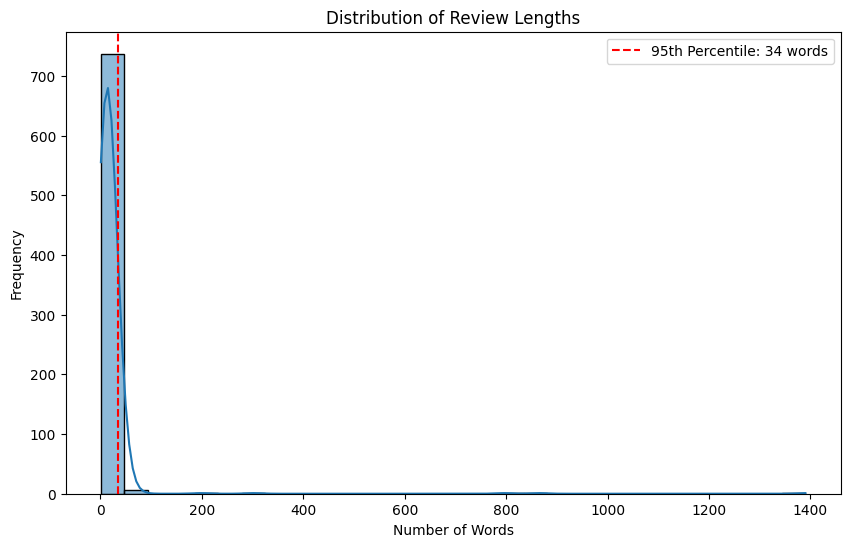

List of unusual characters: ['-', '.', '&', "'", '"', '\x96', '?', ';', '/', ':', '*', '(', ')', '!', '$', '+', '%', '\x97']
Vocabulary size: 4248
Proposed embedding length: 100
Max sequence length: 34
Length of training set: 523
Length of validation set: 112
Length of testing set: 113
     0   1    2     3   4   5    6     7    8     9  ...    26   27  28    29  \
0    0   0    0     0   0   0    0     0    0     0  ...   164  501  22  2201   
1  842  17  306  1193  43  41   81   326  779  1127  ...    87   45  64     8   
2    0   0    0     0   0   0    0     0    0     0  ...  1906  187  74     7   
3  519   4    1    12   5   3  296  2674   42    21  ...     5   14  51    54   
4    0   0    0     0   0   0    0     0    0     0  ...     0    0   0     7   

     30    31    32    33  Sentiment    Set  
0  2202    17  2203  1027          0  Train  
1   504     9   234   874          1  Train  
2    11  1907    17  1908          0  Train  
3  2679    10     1  2680          1  Trai

C:\Users\LorraineFerrusi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.4885 - loss: 0.6930 - val_accuracy: 0.5625 - val_loss: 0.6893
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6570 - loss: 0.6723 - val_accuracy: 0.5179 - val_loss: 0.6843
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6409 - loss: 0.5807 - val_accuracy: 0.6518 - val_loss: 0.6352
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.8676 - loss: 0.3997 - val_accuracy: 0.5804 - val_loss: 1.4888
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9110 - loss: 0.2867 - val_accuracy: 0.5982 - val_loss: 2.5136
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7972 - loss: 0.5723 - val_accuracy: 0.6339 - val_loss: 0.6684
Training stopped at epoch: 6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 34, 100)             │         500,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │         117,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,852,133 (7.07 MB)

 Trainable params: 617,377 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,234,756 (4.71 MB)

None


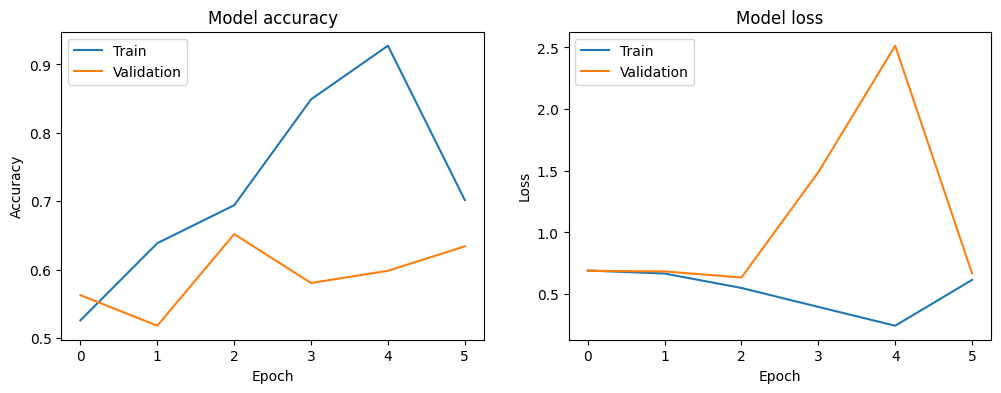

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6288 - loss: 0.6689


Test Accuracy: 63.72%


In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import tensorflow as tf

# load the dataset
text_file = pd.read_csv('C:\\Users\\LorraineFerrusi\\OneDrive - The Information Lab\\Documents\\Personal\\WGU\\D213\\Task 2\\sentiment+labelled+sentences\\sentiment labelled sentences\\imdb_labelled.txt', delimiter='\t', header=None, on_bad_lines='skip')
text_file.columns = ['Review', 'Sentiment']

# 1. Presence of Unusual Characters
def find_unusual_characters(text):
    return re.findall(r'[^\w\s,]', text)

text_file['Unusual_Characters'] = text_file['Review'].apply(find_unusual_characters)
unusual_characters = text_file['Unusual_Characters'].explode().dropna().unique()

# 2. Vocabulary Size
all_words = ' '.join(text_file['Review']).split()
vocabulary_size = len(set(all_words))

# 3. Proposed Word Embedding Length
# common practice is to use 50, 100, or 300 dimensions for word embeddings.
proposed_embedding_length = 100

# 4. Statistical Justification for the Chosen Maximum Sequence Length
review_lengths = text_file['Review'].apply(lambda x: len(x.split()))
max_sequence_length = review_lengths.quantile(0.95)  # choosing 95th percentile as the max sequence length

# plotting the distribution of review lengths
plt.figure(figsize=(10, 6))
sns.histplot(review_lengths, bins=30, kde=True)
plt.axvline(max_sequence_length, color='r', linestyle='--', label=f'95th Percentile: {int(max_sequence_length)} words')
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# display results
print(f'List of unusual characters: {unusual_characters.tolist()}')
print(f'Vocabulary size: {vocabulary_size}')
print(f'Proposed embedding length: {proposed_embedding_length}')
print(f'Max sequence length: {int(max_sequence_length)}')

# 5. Initialize the tokenizer
tokenizer = Tokenizer(num_words=5000)  # Limit to top 5000 words
tokenizer.fit_on_texts(text_file['Review'])

# convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(text_file['Review'])

# 6. Pad sequences to ensure uniform length
max_sequence_length = 34  # As determined from EDA
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length)

# display the first few tokenized and padded sequences
padded_sequences[:5]
ps_data = pd.DataFrame(padded_sequences)

ps_data

# 7. Split the data into sets
# features and labels
X = padded_sequences
y = text_file['Sentiment']

# split into training and remaining (validation + test)
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.7, random_state=42)

# split remaining into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, train_size=0.5, random_state=42)

# display the sizes of the splits
print(f'Length of training set: {len(X_train)}')
print(f'Length of validation set: {len(X_val)}')
print(f'Length of testing set: {len(X_test)}')

# convert the numpy arrays to DataFrames
train_df = pd.DataFrame(X_train)
val_df = pd.DataFrame(X_val)
test_df = pd.DataFrame(X_test)

# add the labels to each DataFrame
train_df['Sentiment'] = y_train.values
val_df['Sentiment'] = y_val.values
test_df['Sentiment'] = y_test.values

# add a column to indicate the set
train_df['Set'] = 'Train'
val_df['Set'] = 'Validation'
test_df['Set'] = 'Test'

# concatenate the DataFrames
combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# display the combined DataFrame
print(combined_df.head())

# convert to csv files
combined_df.to_csv('C:\\Users\\LorraineFerrusi\\OneDrive - The Information Lab\\Documents\\Personal\\WGU\\D213\\Task 2\\prepared_data.csv', index=False)

# set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# define the model
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=100, input_length=34))
model.add(LSTM(units=128, return_sequences=False))
model.add(Dropout(rate=0.5))
model.add(Dense(units=1, activation='sigmoid'))

# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# train the model with early stopping
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping])

# print the final epoch
final_epoch = len(history.epoch)
print(f'Training stopped at epoch: {final_epoch}')

# print the model summary
print(model.summary())

# plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

# evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

# save the entire model to a file
model.save('trained_model.h5')